In [ ]:
   import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import kagglehub
import os
from sklearn.impute import SimpleImputer   # missing value
import seaborn as sns
import matplotlib.pyplot as plt

import kagglehub

# Download latest version
path = kagglehub.dataset_download("pvaibhav1995/covid19-worldometer-dataset")

print("Path to dataset files:", path)

csv_path = os.path.join(path,"Worldometer Dataset.csv" )


df = pd.read_csv(csv_path, encoding='latin1')

print(df.head())
print(df.isnull().sum())

print(df.columns.tolist())

Using Colab cache for faster access to the 'covid19-worldometer-dataset' dataset.
Path to dataset files: /kaggle/input/covid19-worldometer-dataset
   Country Total Cases New Cases Total Deaths New Deaths Total Recovered  \
0      USA    5,02,876    33,752       18,747      2,035          27,314   
1    Spain    1,58,273     5,051       16,081        634          55,668   
2    Italy    1,47,577     3,951       18,849        570          30,455   
3   France    1,24,869     7,120       13,197        987          24,932   
4  Germany    1,22,171     3,936        2,736        129          53,913   

  Active Cases Serious, Critical Tot Cases/1M pop  Deaths/1M pop Total Tests  \
0     4,56,815            10,917            1,519           57.0   25,38,888   
1       86,524             7,371            3,385          344.0    3,55,000   
2       98,273             3,497            2,441          312.0    9,06,864   
3       86,740             7,004            1,913          202.0    3,33,807

In [ ]:
## Solving missing values



# seperate the num and cate
num_cols = ['Total Cases', 'New Cases', 'Total Deaths', 'New Deaths', 'Total Recovered', 'Active Cases', 'Serious, Critical', 'Tot\xa0Cases/1M pop', 'Deaths/1M pop', 'Total Tests', 'Tests/1M pop']
cat_cols = ['Country']



!!! NOTICE
# converse to numeric real
for col in num_cols:
    df[col] = df[col].astype(str).str.replace(",", "")
    df[col] = pd.to_numeric(df[col], errors="coerce")

# set the missing value = 0
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])


In [ ]:
## labeling

# -> this method is creation a new meaning feature that the goal of task

df['DeathRate'] = (df['Total Deaths']/df['Total Cases'])


# define categorical function to classify each volume
def categorical(rate) :
  if rate < 0.01 :
     return 0
  elif rate < 0.03 :
     return 1
  else :
     return 2

# label storing
df['labels'] = df['DeathRate'].apply(categorical)




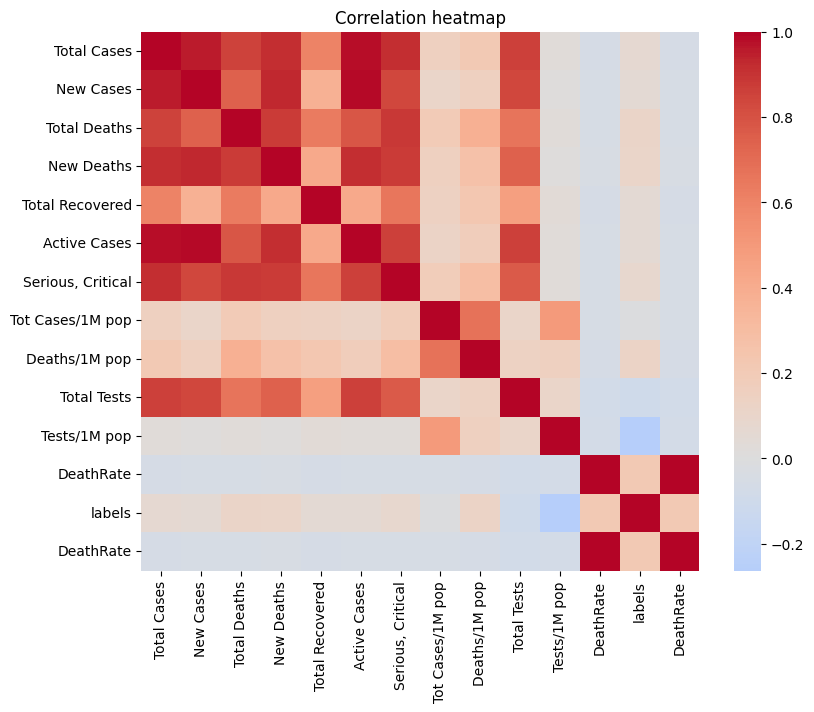

In [ ]:
## Search for meaning features to decrease noise

import seaborn as sns
# -> 2 options : heat map & correlation matrix (meaning at Git)


# summarize the numeric collums to correlate
num_col_for_corr = df.select_dtypes(include=['int64','float64']).columns.tolist()


# main logic to search do correlation heat map :
corr = df[num_col_for_corr + ['DeathRate']].corr(method = 'pearson')


# show

plt.figure(figsize=(9,7))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()





In [ ]:
## Filtering data
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold = 0.01)
X_filtered = sel.fit_transform(df[num_col_for_corr]) # VarianceThreshold return a Numpy by default

# correlation matrix
corr_matrix = df[num_col_for_corr].corr().abs()

# select upper triangle of matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# drop features with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
df_reduced = df.drop(columns=to_drop)

print("Dropped features:", to_drop)


corr_with_target = df[num_col_for_corr].corrwith(df['DeathRate']).abs()
top_features = corr_with_target.sort_values(ascending=False).head(5)
print("Top correlated features:\n", top_features)


Dropped features: ['New Cases', 'New Deaths', 'Active Cases', 'Serious, Critical']
Top correlated features:
 DeathRate        1.000000
labels           0.217004
Total Tests      0.075120
Tests/1M pop     0.072294
Deaths/1M pop    0.058841
dtype: float64


In [ ]:
## Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

x = df[num_col_for_corr]
y = df['labels']

# split data for train or test

x_train,x_test,y_train,y_test = train_test_split(
    x,y, test_size = 0.2, random_state = 42, stratify = y
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
## Training model

from sklearn.linear_model import SGDClassifier

model = SGDClassifier(loss = "log_loss", max_iter = 1000, tol = 1e-42, random_state = 42)
model.fit(x_train,y_train)


SGDClassifier(loss='log_loss', random_state=42, tol=1e-42)

Accuracy: 0.9767441860465116

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.91      1.00      0.95        10
           2       1.00      0.96      0.98        28

    accuracy                           0.98        43
   macro avg       0.97      0.99      0.98        43
weighted avg       0.98      0.98      0.98        43



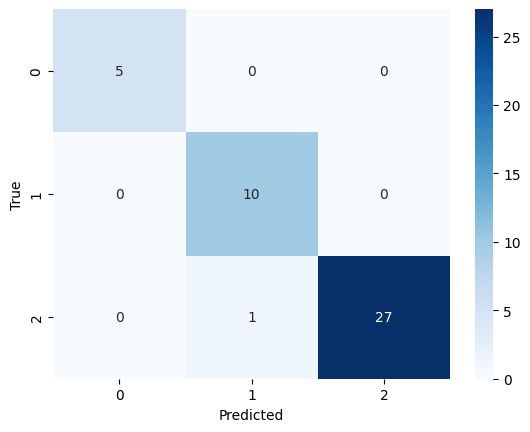

In [ ]:
## prediction

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)


sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Notice : Filtering data, Search for noises data

-> HOW TO USE THAT LIB

         library : VarianceThreshold, accuracy_score, classification_matrix, train_test_split, accuracy_score, confusion_matrix, classification_report,








